Recommended to use virtual env:

1. python -m venv .venv
2. .venv\Scripts\activate
3. pip install -r requirements.txt

## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot

df = pd.read_csv('Fifa_world_cup_matches.csv', encoding='latin-1')

In [3]:
# Adds new 'result' column. 1 = Win, 0 = Loss
# Tracks whether Team 1 won or not.
goals_team_1 = pd.to_numeric(df['number of goals team1'])
goals_team_2 = pd.to_numeric(df['number of goals team2'])
df['result'] = (goals_team_1 > goals_team_2).astype(int)

# Stage Feature, Organized Group Stage and Knockouts (incl. quarters, semis, finals etc..)
df['stage_type'] = np.where(df['category'].str.startswith('Group'), 'Group', 'Knockout')

# Unneccesary Columns
df = df.drop(columns = ['team1', 'team2', 'date', 'hour']) 

# Columns that give away the result of the match
df = df.drop(columns = [
    'number of goals team1','number of goals team2',
    'conceded team1','conceded team2',
    'penalties scored team1','penalties scored team2',
    'goal inside the penalty area team1','goal inside the penalty area team2',
    'goal outside the penalty area team1','goal outside the penalty area team2',
    'own goals team1','own goals team2',
    'assists team1','assists team2'
])


In [4]:
# Looks for cells with % in them and converts them into decimal (eg 56% -> 0.56)
percent_cols = [c for c in df.columns if df[c].astype(str).str.contains('%', na=False).any()]
if percent_cols:
    df[percent_cols] = df[percent_cols].apply(
        lambda col: col.astype(str).str.replace(r'[%\s]', '', regex=True).replace('', pd.NA).astype(float) / 100
    )

In [5]:
# Calculate differences
import re

x_temp = df.iloc[:, :-1] # Selects all but the result column

team1_cols = x_temp.filter(like='team1').columns
team2_cols = x_temp.filter(like='team2').columns

def base_name(col):
    return re.sub(r'(?i)\s*team1\s*$', '', col).strip()

diff_features = pd.DataFrame(index=x_temp.index)
diff_col_names = [f'{base_name(c)} diff' for c in team1_cols]

for i in range(len(team1_cols)):
    col1 = team1_cols[i]
    col2 = team2_cols[i]
    diff_col = diff_col_names[i]

    diff_features[diff_col] = x_temp[col1] - x_temp[col2]

In [6]:
# FINAL DATAFRAME
final_df = diff_features.copy()
final_df['result'] = df.loc[diff_features.index, 'result']
final_df['is_knockout'] = (df.loc[diff_features.index, 'stage_type'] == 'Knockout').astype(int)

X = final_df.drop(columns=['result'])
y = final_df['result']

In [7]:
from sklearn.model_selection import train_test_split
# 20% Test / 80% Train
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 17, test_size = 0.2)

## Logistic Regression

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score

print('Class distribution (train):', y_train.value_counts(normalize=True).to_dict())

log_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=500,
        class_weight='balanced',
        C=1.0,
        solver='lbfgs',
        random_state=42
    ))
])

log_reg_pipe.fit(X_train, y_train)
y_pred_lr = log_reg_pipe.predict(X_test)
y_prob_lr = log_reg_pipe.predict_proba(X_test)[:, 1]

print('LogReg accuracy:', accuracy_score(y_test, y_pred_lr))
print('LogReg ROC AUC:', roc_auc_score(y_test, y_prob_lr))
print(classification_report(y_test, y_pred_lr))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred_lr))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(log_reg_pipe, X, y, cv=cv, scoring='roc_auc')
print('CV ROC AUC mean:', cv_auc.mean(), 'std:', cv_auc.std())

Class distribution (train): {0: 0.5882352941176471, 1: 0.4117647058823529}
LogReg accuracy: 0.6923076923076923
LogReg ROC AUC: 0.725
              precision    recall  f1-score   support

           0       0.60      0.60      0.60         5
           1       0.75      0.75      0.75         8

    accuracy                           0.69        13
   macro avg       0.68      0.68      0.68        13
weighted avg       0.69      0.69      0.69        13

Confusion matrix:
 [[3 2]
 [2 6]]
CV ROC AUC mean: 0.7114285714285714 std: 0.05071819792645463


### Extract Coefficients

In [9]:
log_reg = log_reg_pipe.named_steps['clf']
coef = log_reg.coef_[0]

features = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': coef,
    'abs_value': np.abs(coef)
}).sort_values(by='abs_value', ascending=False)

print(features.head(15))

                            feature  coefficient  abs_value
2           on target attempts diff     1.445023   1.445023
29                     corners diff     0.869169   0.869169
32            forced turnovers diff     0.826381   0.826381
27           crosses completed diff    -0.645378   0.645378
0                   possession diff    -0.597225   0.597225
21                   red cards diff     0.594755   0.594755
8              central channel diff     0.593120   0.593120
7          left inside channel diff    -0.589119   0.589119
16       attempted line breaks diff     0.532452   0.532452
6                 left channel diff     0.525093   0.525093
22               fouls against diff    -0.493816   0.493816
26                     crosses diff    -0.441506   0.441506
12  inbehind offers to receive diff    -0.432490   0.432490
17       completed line breaks diff     0.376885   0.376885
10               right channel diff    -0.352892   0.352892


### Visualize the findings

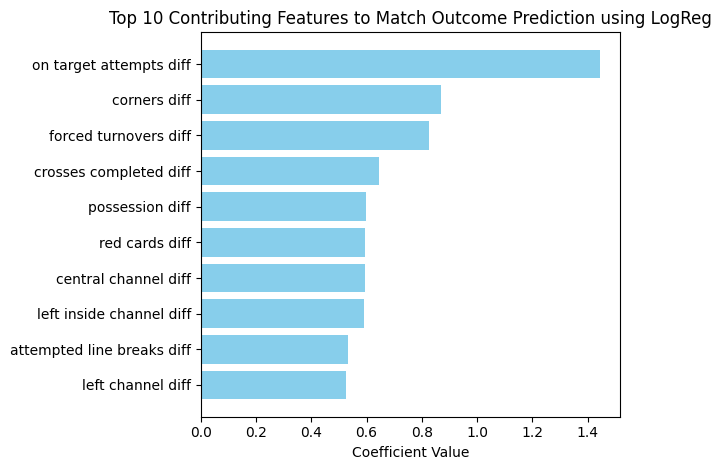

In [10]:
top_features = features.head(10)

pyplot.figure()
pyplot.barh(top_features['feature'], top_features['abs_value'], color='skyblue')
pyplot.xlabel('Coefficient Value')
pyplot.title('Top 10 Contributing Features to Match Outcome Prediction using LogReg')
pyplot.gca().invert_yaxis()
pyplot.tight_layout()
pyplot.show()

### LogReg Interpretation:

**Class Distribution on training data** <br>
Accuracy if you always assumed lose/win for a given matchup, naively: <br>
Class 0 (Loss): ~58% <br>
Class 1 (Win): ~41% <br>

**ROC AUC (Receiver Operating Characteristics Area Under the Curve):** <br>
Probability the model ranks a random given Win, higher than a random given loss. Basically a metric to show how well it performed at predicting the result. 1 is perfect, 0.5 is like guessing randomly: <br>
<br>
ROC AUC: 0.725 (Can be determined as useful)<br>

**Cross Validation (CV) AUC Mean/Std** <br>
ROC AUC Score on unseen data: <br> <br>
Mean: 0.71 <br>
Standard Deviation: 0.05 <br>
(Very similar to the testing AUC ROC score. Low std shows score is stable across folds)

**LogReg Accuracy:** <br>
Predicts ~69% of match outcomes. <br>
| Class    | Precision | Recall | F1   |
|----------|-----------|--------|------|
| 0 (Lose) | 0.60      | 0.60   | 0.60 |
| 1 (Win)  | 0.75      | 0.75   | 0.75 |


... And is better at predicting a win rather than a loss.

**Confusion Matrix**
To support the LogReg accuracy:

| Actual   | Predicted 0 (Loss) | Predicted 1 (Win) |
|----------|--------------------|-------------------|
| 0 (Lose) | 3                  | 2                 |
| 1 (Win)  | 2                  | 6                 |



## XGBoost

In [11]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

print('Class distribution (train):', y_train.value_counts(normalize=True).to_dict())

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight (neg/pos): {scale_pos_weight:.2f}')

xgb_model = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.1,
    subsample=0.6,
    colsample_bytree=0.6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=10
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print('\nXGBoost accuracy:', accuracy_score(y_test, y_pred_xgb))
print('XGBoost ROC AUC:', roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred_xgb))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_cv = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.1,
    subsample=0.6,
    colsample_bytree=0.6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc'
)
cv_auc = cross_val_score(xgb_cv, X, y, cv=cv, scoring='roc_auc')
print('\nCV ROC AUC mean:', cv_auc.mean(), 'std:', cv_auc.std())

Class distribution (train): {0: 0.5882352941176471, 1: 0.4117647058823529}
scale_pos_weight (neg/pos): 1.43

XGBoost accuracy: 0.5384615384615384
XGBoost ROC AUC: 0.775
              precision    recall  f1-score   support

           0       0.43      0.60      0.50         5
           1       0.67      0.50      0.57         8

    accuracy                           0.54        13
   macro avg       0.55      0.55      0.54        13
weighted avg       0.58      0.54      0.54        13

Confusion matrix:
 [[3 2]
 [4 4]]

CV ROC AUC mean: 0.6533333333333333 std: 0.06269821177383922


### Extract Importance Values

In [12]:
xgb_importances = xgb_model.feature_importances_

xgb_features = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_importances,
    'abs_importance': np.abs(xgb_importances)
}).sort_values(by='abs_importance', ascending=False)

print(xgb_features.head(15))

                                  feature  importance  abs_importance
31                  goal preventions diff    0.166966        0.166966
1                     total attempts diff    0.050031        0.050031
7                left inside channel diff    0.049064        0.049064
2                 on target attempts diff    0.046811        0.046811
13       inbetween offers to receive diff    0.044100        0.044100
8                    central channel diff    0.043293        0.043293
29                           corners diff    0.039584        0.039584
25                  passes completed diff    0.039574        0.039574
4   attempts inside the penalty area diff    0.034231        0.034231
11           total offers to receive diff    0.033747        0.033747
33       defensive pressures applied diff    0.033426        0.033426
22                     fouls against diff    0.032939        0.032939
9               right inside channel diff    0.032327        0.032327
23                  

### Visualize Findings

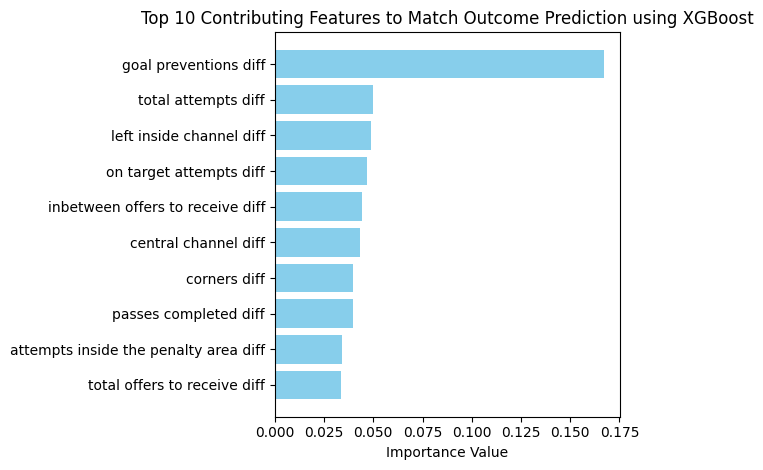

In [13]:
top_features = xgb_features.head(10)

pyplot.figure()
pyplot.barh(top_features['feature'], top_features['abs_importance'], color='skyblue')
pyplot.xlabel('Importance Value')
pyplot.title('Top 10 Contributing Features to Match Outcome Prediction using XGBoost')
pyplot.gca().invert_yaxis()
pyplot.tight_layout()
pyplot.show()

## Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

print('Class distribution (train):', y_train.value_counts(normalize=True).to_dict())

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=2, 
    min_samples_split=5,
    min_samples_leaf=2,  
    max_features='sqrt', 
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print('\nRandom Forest accuracy:', accuracy_score(y_test, y_pred_rf))
print('Random Forest ROC AUC:', roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred_rf))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc_rf = cross_val_score(rf_model, X, y, cv=cv, scoring='roc_auc')
print('\nCV ROC AUC mean:', cv_auc_rf.mean(), 'std:', cv_auc_rf.std())




Class distribution (train): {0: 0.5882352941176471, 1: 0.4117647058823529}

Random Forest accuracy: 0.6923076923076923
Random Forest ROC AUC: 0.7250000000000001
              precision    recall  f1-score   support

           0       0.57      0.80      0.67         5
           1       0.83      0.62      0.71         8

    accuracy                           0.69        13
   macro avg       0.70      0.71      0.69        13
weighted avg       0.73      0.69      0.70        13

Confusion matrix:
 [[4 1]
 [3 5]]

CV ROC AUC mean: 0.6485714285714286 std: 0.08673466720020934


### Extract Important Features

In [15]:
rf_importances = rf_model.feature_importances_

rf_features = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_importances,
    'abs_importance': np.abs(rf_importances)
}).sort_values(by='abs_importance', ascending=False)

print(rf_features.head(15))

                                              feature  importance  \
2                             on target attempts diff    0.104632   
8                                central channel diff    0.086696   
13                   inbetween offers to receive diff    0.083628   
4               attempts inside the penalty area diff    0.063292   
32                              forced turnovers diff    0.053657   
1                                 total attempts diff    0.050117   
31                              goal preventions diff    0.048407   
30                                    free kicks diff    0.041690   
18               attempted defensive line breaks diff    0.040980   
15  receptions between midfield and defensive line...    0.033005   
28                    switches of play completed diff    0.031613   
25                              passes completed diff    0.030271   
26                                       crosses diff    0.028744   
11                       total off

### Visualize Importance Ratings

Reminder: RF rates importance ratings as a percentage

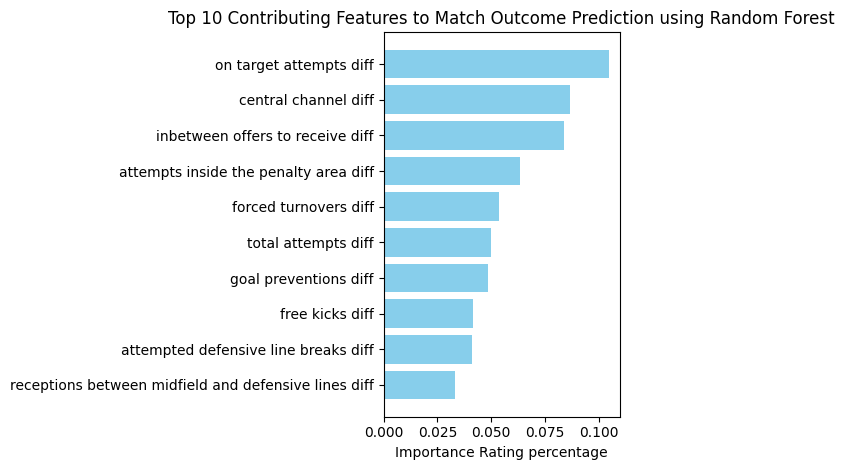

In [16]:
top_features = rf_features.head(10)

pyplot.figure()
pyplot.barh(top_features['feature'], top_features['abs_importance'], color='skyblue')
pyplot.xlabel('Importance Rating percentage')
pyplot.title('Top 10 Contributing Features to Match Outcome Prediction using Random Forest')
pyplot.gca().invert_yaxis()
pyplot.tight_layout()
pyplot.show()

# CatBoost

In [17]:
from catboost import CatBoostClassifier

# Startup CatBoost
cat_model = CatBoostClassifier(
    iterations=500, learning_rate = 0.1, depth=6, eval_metric='Logloss',
    random_state=42, verbose=False,
    class_weights=[1, (y_train == 0).sum() / (y_train == 1).sum()]
)

# Fit
cat_model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

# Predict
y_pred_cat = cat_model.predict(X_test)
y_prob_cat = cat_model.predict_proba(X_test)[:, 1]

# Evaluate
print('\nCatBoost accuracy:', accuracy_score(y_test, y_pred_cat))
print('CatBoost ROC AUC:', roc_auc_score(y_test, y_prob_cat))
print(classification_report(y_test, y_pred_cat))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred_cat))


CatBoost accuracy: 0.6923076923076923
CatBoost ROC AUC: 0.75
              precision    recall  f1-score   support

           0       0.57      0.80      0.67         5
           1       0.83      0.62      0.71         8

    accuracy                           0.69        13
   macro avg       0.70      0.71      0.69        13
weighted avg       0.73      0.69      0.70        13

Confusion matrix:
 [[4 1]
 [3 5]]


### Extract Features

In [18]:
cat_importances = cat_model.get_feature_importance()

cat_features = pd.DataFrame({
    'feature': X_train.columns,
    'importance': cat_importances,
    'abs_importance': np.abs(cat_importances)
}).sort_values(by='abs_importance', ascending=False)

print(cat_features.head(15))

                                  feature  importance  abs_importance
0                         possession diff   12.447831       12.447831
4   attempts inside the penalty area diff   11.111075       11.111075
8                    central channel diff    6.824505        6.824505
31                  goal preventions diff    5.391270        5.391270
11           total offers to receive diff    5.290368        5.290368
20                      yellow cards diff    4.812304        4.812304
22                     fouls against diff    4.098708        4.098708
27                 crosses completed diff    3.974824        3.974824
17             completed line breaks diff    3.847650        3.847650
9               right inside channel diff    3.629503        3.629503
25                  passes completed diff    3.218519        3.218519
12        inbehind offers to receive diff    3.174637        3.174637
14         infront offers to receive diff    3.170937        3.170937
33       defensive p

### Visualize Findings

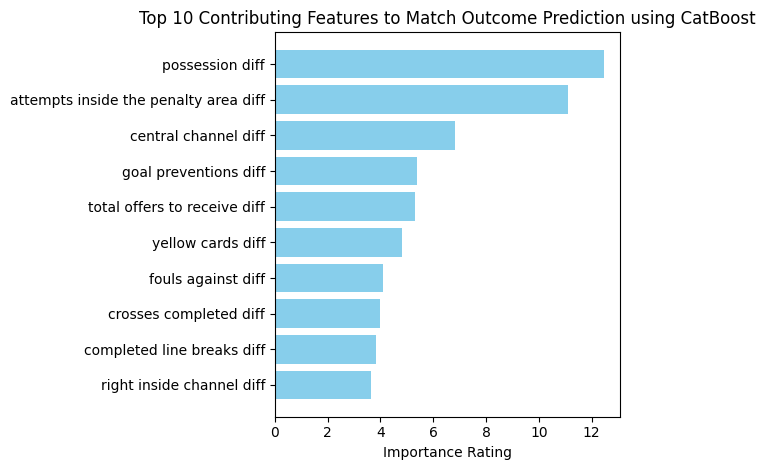

In [19]:
top_features = cat_features.head(10)

pyplot.figure()
pyplot.barh(top_features['feature'], top_features['abs_importance'], color='skyblue')
pyplot.xlabel('Importance Rating')
pyplot.title('Top 10 Contributing Features to Match Outcome Prediction using CatBoost')
pyplot.gca().invert_yaxis()
pyplot.tight_layout()
pyplot.show()

# Compare Per-Match Results

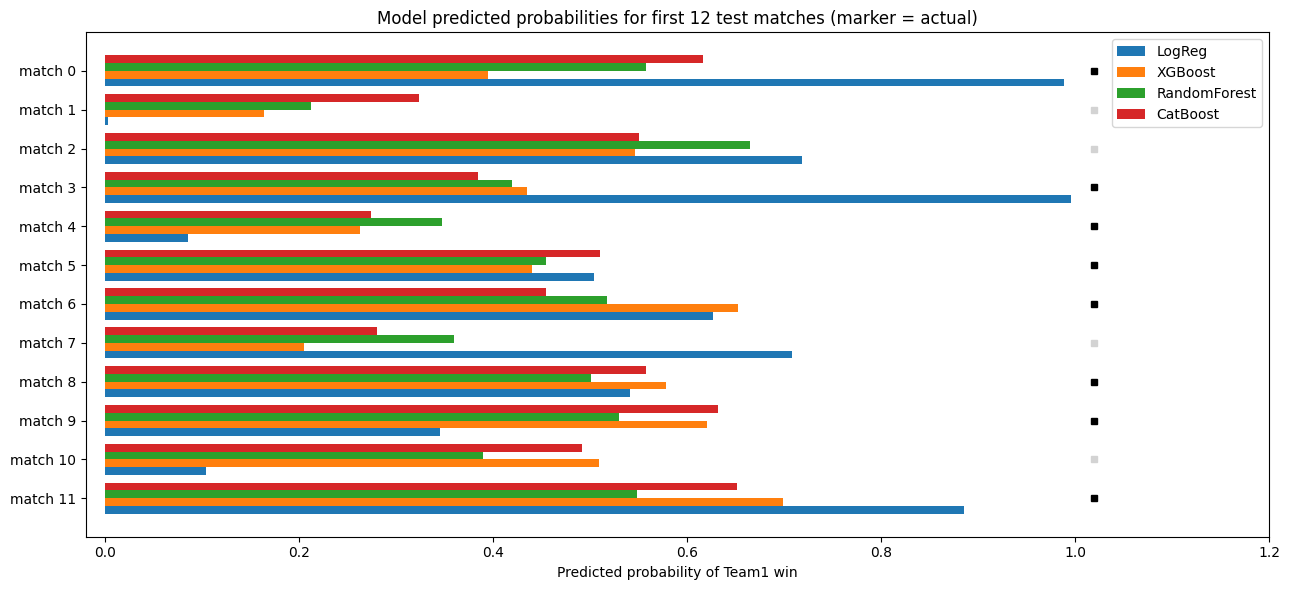

In [ ]:
results_df = X_test.copy()
results_df['actual'] = y_test
results_df['pred_lr'] = y_pred_lr
results_df['prob_lr'] = y_prob_lr
results_df['pred_xgb'] = y_pred_xgb
results_df['prob_xgb'] = y_prob_xgb
results_df['pred_rf'] = y_pred_rf
results_df['prob_rf'] = y_prob_rf
results_df['pred_cat'] = y_pred_cat
results_df['prob_cat'] = y_prob_cat

# correctness flags
results_df['correct_lr'] = results_df['pred_lr'] == results_df['actual']
results_df['correct_xgb'] = results_df['pred_xgb'] == results_df['actual']
results_df['correct_rf'] = results_df['pred_rf'] == results_df['actual']
results_df['correct_cat'] = results_df['pred_cat'] == results_df['actual']

display_cols = ['actual',
                'prob_lr','pred_lr','correct_lr',
                'prob_xgb','pred_xgb','correct_xgb',
                'prob_rf','pred_rf','correct_rf',
                'prob_cat','pred_cat','correct_cat']

N = 12
plot_df = results_df[display_cols].head(N).reset_index(drop=True)

pyplot.figure(figsize=(13, 6))
x = np.arange(len(plot_df))
width = 0.2

pyplot.barh(x + width*1.5, plot_df['prob_lr'], height=width, label='LogReg', color='tab:blue')
pyplot.barh(x + width*0.5, plot_df['prob_xgb'], height=width, label='XGBoost', color='tab:orange')
pyplot.barh(x - width*0.5, plot_df['prob_rf'], height=width, label='RandomForest', color='tab:green')
pyplot.barh(x - width*1.5, plot_df['prob_cat'], height=width, label='CatBoost', color='tab:red')

# (1=win, 0=loss)
for i, a in enumerate(plot_df['actual']):
    pyplot.plot([1.02], [i], marker='s', color='k' if a==1 else 'lightgray', markersize=4)

pyplot.yticks(x, [f"match {i}" for i in x])
pyplot.xlabel('Predicted probability of Team1 win')
pyplot.title(f'Model predicted probabilities for first {N} test matches (black = win))')
pyplot.xlim(-0.02, 1.2)
pyplot.legend(loc='upper right')
pyplot.gca().invert_yaxis()
pyplot.tight_layout()
pyplot.show()
